<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/04_PoseEstimation/pose_estimation_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **23. 행동 스티커 만들기**

## **23-1. 들어가며**

**[아이스브레이킹] 2000년 그래픽 디자이너 김득헌이 제작한 스틱맨 플래시 캐릭터의 이름은 무엇인가요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

사랑과, 정의를, (빙글빙글빙글) 지키는 **졸라맨**~ 죄없는 선량한 시민을 괴롭히다니, 내가 정의의 이름으로 널 용서하지 않겠다!</details>

이번 시간에는 Pose estimation 모델을 학습시키기 위해 활용할 수 있는 데이터셋(MPII Human Pose Dataset)에 대해 알아보고, pre-trained 된 가중치를 활용하여 테스트 이미지로 직접 모델의 성능을 확인해 볼 예정입니다.

### **MPII 데이터셋 다운로드하기**
---

오늘은 MPII Human Pose Dataset을 사용해서 Human Pose Estimation task를 위한 모델을 훈련시켜 보겠습니다.

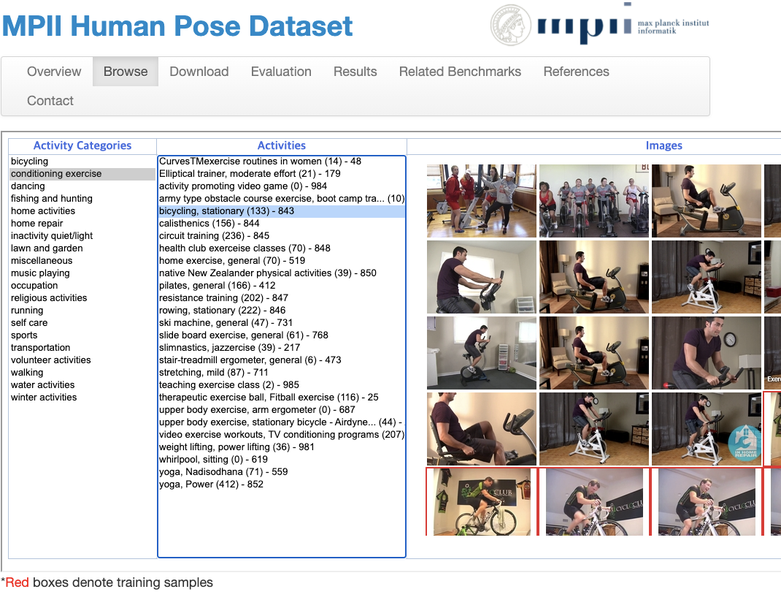

http://human-pose.mpi-inf.mpg.de/#download

> (주의) mpii_human_pose_v1.tar.gz 파일은 무려 12GB가 넘는 용량을 가지고 있습니다. 공식 홈페이지에서 다운로드시 수 시간이 소요될 수 있으므로 학습전 미리 다운로드해 두시기를 권합니다.



```
$ sudo apt install unzip # unzip 이 없는 경우
$ mkdir -p ~/aiffel/mpii
$ cd ~/aiffel/mpii

$ wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
$ wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip
$ tar -xvf mpii_human_pose_v1.tar.gz -C .
$ unzip mpii_human_pose_v1_u12_2.zip
```



In [5]:
! sudo apt install unzip # unzip 이 없는 경우
! mkdir -p ./aiffel/mpii
! cd ./aiffel/mpii

! wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz -P ./aiffel/mpii
! wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip -P ./aiffel/mpii
! tar -xf ./aiffel/mpii/mpii_human_pose_v1.tar.gz -C ./aiffel/mpii
! unzip -q ./aiffel/mpii/mpii_human_pose_v1_u12_2.zip -d ./aiffel/mpii

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
--2026-09-04 06:26:05--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12088943206 (11G) [application/x-gzip]
Saving to: ‘./aiffel/mpii/mpii_human_pose_v1.tar.gz’

mpii_human_pose_v1. 100%[===================>]  11.26G  7.68MB/s    in 12m 45s 

2026-09-04 06:38:51 (15.1 MB/s) - ‘./aiffel/mpii/mpii_human_pose_v1.tar.gz’ saved [12088943206/12088943206]

--2026-09-04 06:38:51--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.m

`mpii_human_pose_v1_u12_2.zip` 을 풀어보면 `mpii_human_pose_v1_u12_1.mat` 파일이 나와서 열어보기 불편한데요. 파이썬에서 읽기 쉽도록 json 파일로 변환해 두었습니다.



```
$ cd ~/aiffel/mpii/mpii_human_pose_v1_u12_2
$ wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
$ wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
```



In [6]:
! cd ./aiffel/mpii/mpii_human_pose_v1_u12_2
! wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
! wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
! mv train.json ./aiffel/mpii/mpii_human_pose_v1_u12_2/
! mv validation.json ./aiffel/mpii/mpii_human_pose_v1_u12_2/

--2026-09-04 06:41:44--  https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.100, 3.165.160.23, 3.165.160.58, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31043010 (30M) [application/json]
Saving to: ‘train.json’

train.json          100%[===================>]  29.60M  --.-KB/s    in 0.1s    

2026-09-04 06:41:44 (277 MB/s) - ‘train.json’ saved [31043010/31043010]

--2026-09-04 06:41:44--  https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.100, 3.165.160.23, 3.165.160.58, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4127396 (3.9M) [application/js

[mpii.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip) \
\
마지막으로, 오늘의 실습 코드를 프로젝트로 구성한 파일을 첨부합니다. 위의 `mpii.zip`을 다운로드하여 `~/aiffel/mpii` 디렉토리에 압축을 풀어주세요.



```
$ wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii.zip -P ~/aiffel/mpii
$ cd ~/aiffel/mpii && unzip mpii.zip
```



In [7]:
! wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip -O mpii.zip
! unzip ./mpii.zip -d ./aiffel/mpii

--2026-09-04 06:41:44--  https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.100, 3.165.160.23, 3.165.160.58, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12488 (12K) [application/zip]
Saving to: ‘mpii.zip’

mpii.zip            100%[===================>]  12.20K  --.-KB/s    in 0.001s  

2026-09-04 06:41:45 (22.4 MB/s) - ‘mpii.zip’ saved [12488/12488]

Archive:  ./mpii.zip
  inflating: ./aiffel/mpii/hourglass104.py  
   creating: ./aiffel/mpii/models/
  inflating: ./aiffel/mpii/preprocess.py  
  inflating: ./aiffel/mpii/simplebaseline.py  
  inflating: ./aiffel/mpii/test.py   
  inflating: ./aiffel/mpii/tfrecords_mpii.py  
  inflating: ./aiffel/mpii/train.py  
  inflating: ./aiffel/mpii/Untitled.ipynb  


이번 노드에서는 이 프로젝트 파일을 편집하여 진행합니다. `.py` 파일 형태 자료를 확인하면 도움이 되실거예요.

## **23-2. 데이터 전처리하기**

우선 필요한 패키지를 설치해 주세요.



```
$ pip install ray
```



In [8]:
! pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 9.7 MB/s eta 0:00:00


앞으로 사용할 라이브러리를 불러옵니다. 고정해서 사용할 변수도 만들어 두죠.

In [9]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F

import ray

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = './aiffel/mpii'
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

print('슝=3')

슝=3


### **json 파싱하기**

이전 스텝에서 `train.json`과 `validation.json` 파일이 소개된 것을 기억하시나요? 이 파일들은 이미지에 담겨 있는 사람들의 pose keypoint 정보들을 가지고 있어서 Pose Estimation을 위한 label로 삼을 수 있습니다. \
\
우선 json이 어떻게 구성되어 있는지 파악해 보기 위해 json 파일을 열어 샘플로 annotation 정보를 1개만 출력해 봅시다. `json.dumps()`를 활용해서 좀 더 명확하게 하면 더욱 좋습니다.

In [10]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


`joints` 가 우리가 label 로 사용할 keypoint 의 label 입니다. 이미지 형상과 사람의 포즈에 따라 모든 label 이 이미지에 나타나지 않기 때문에 `joints_vis` 를 이용해서 실제로 사용할 수 있는 keypoint 인지 나타냅니다. MPII 의 경우 1 (visible) / 0(non) 으로만 나누어지기 때문에 조금 더 쉽게 사용할 수 있습니다. coco 의 경우 2 / 1 / 0 으로 표현해서 occlusion 상황까지 label 화 되어 있습니다. \
\
`joints` 순서는 아래와 같은 순서로 배치되어 저장해 뒀습니다.

* 0 - 오른쪽 발목
* 1 - 오른쪽 무릎
* 2 - 오른쪽 엉덩이
* 3 - 왼쪽 엉덩이
* 4 - 왼쪽 무릎
* 5 - 왼쪽 발목
* 6 - 골반
* 7 - 가슴(흉부)
* 8 - 목
* 9 - 머리 위
* 10 - 오른쪽 손목
* 11 - 오른쪽 팔꿈치
* 12 - 오른쪽 어깨
* 13 - 왼쪽 어깨
* 14 - 왼쪽 팔꿈치
* 15 - 왼쪽 손목

`scale`과 `center`는 사람 몸의 크기와 중심점 입니다. `scale`은 200을 곱해야 온전한 크기가 됩니다. 추후에 전처리 과정에서 200을 곱해서 사용할 예정이에요. \
\
이제 json annotation 을 파싱하는 함수를 만들어 보겠습니다.

In [11]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

print('슝=3')

슝=3


한 번 `parse_one_annotation()`함수를 테스트 해봅시다.

In [12]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': './aiffel/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


이제 우리가 원하는 정보만 뽑아낼 수 있게 되었네요. 다음으로 넘어가보죠.

**Q. MPII 데이터셋에서 json 파일에서 'scale' 정보가 의미하는 바는 무엇인가요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

MPII 데이터셋에서 'scale'은 사람의 크기 비율을 나타내는데, 관절의 위치 및 사람의 신체 부분 크기를 상대적으로 표현하는 데 사용됩니다. \
일반적으로 관절의 좌표는 이미지의 크기에 따라 상대적으로 바뀌는 값이기 때문에 이를 보정하기 위해 scale 값을 제공하는 것이며, 이를 통해서 다른 크기의 이미지에서도 신체 부위의 위치를 일관성 있게 분석할 수 있습니다.</details>

## **23-3. DataLoader 파일 만들기**

### **DataLoader 파일 만들기**

이전까지는 tf.keras 의 `ImageDataGenerator` 를 이용해서 주로 학습 데이터를 읽었습니다. 하지만 실제 프로젝트에서는 튜토리얼 데이터셋보다 훨씬 큰 크기의 데이터를 다뤄야 합니다. \
\
학습을 많이 해볼수록 학습 속도에 관심을 가지게 되는데요.

<br>일반적으로 학습 과정에서 gpu 의 연산 속도보다 HDD I/O 가 느리기 때문에 병목 현상이 발생하고 대단위 프로젝트 실험에서 효율성이 떨어지는 것을 관찰할 수 있습니다. (답답해요..) \
\
따라서 "학습 데이터를 어떻게 빠르게 읽는가?" 에 대한 고민을 반드시 수행하셔야 더 많은 실험을 할 수 있습니다. \
\
다음 링크를 보고 퀴즈를 풀어 봅시다.<br><br>

* [`torch.utils.data.DataLoader`로 성능 향상하기](https://pytorch.org/docs/stable/data.html)

**Q. 학습 속도를 향상시키기 위해서 데이터 관점에서 고려해야하는 단계는 어떤 단계인가요? 속도 향상을 위한 처리 방법을 위 링크에서 찾아대답해 봅시다.**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

data read(또는 prefetch) 또는 데이터 변환 단계. gpu 학습과 병렬적으로 수행되도록 prefetch를 적용해야 함. 수행방법은 num_workers, pin_memory 등을 사용해야함.</details>

내용이 꽤 어렵습니다만 PyTorch 에서는 위 변환을 자동화해주는 도구를 제공합니다. 데이터셋을 DataLoader 형태로 표현하는 것인데요. DataLoader 는 binary record sequence 를 저장하기 위한 형식입니다. \
\
내부적으로 protocol buffer 라는 것을 이용합니다.<br><br>

* https://developers.google.com/protocol-buffers/?hl=ko

<br>protocol buffer 는 크로스 플랫폼에서 사용할 수 있는 직렬화 데이터 라이브러리라고 생각하시면 됩니다. \
\
데이터를 직렬화 한다는 것은 의미가 있는 정보만 추출해 나열하는 것을 뜻합니다. 예를 들어 "서울 강동구에 사는 32살 고길동"님을 나타내기 위해 "서울강동32고길동"과 같이 쓴다면 데이터만 담을 수 있겠죠? 다만 데이터 형식을 고정해야 하기 때문에 첫 두 글자는 시를 뜻하고, 다음 두 글자는 구를 뜻하고 다음 두 자리 숫자가 오고 이름은 세 글자여야 하는 제한이 생깁니다. 100살이 넘는 사람이나 이름이 세 글자가 아닌 사람을 담을 수 없어요. 그래서 매우 정형화된 데이터는 직렬화 하면 데이터 크기와 처리 속도 측면에서 유리하지만 사용하는데 제한이 있다고 기억하면 좋습니다. 어떤 데이터에서 어떤 방법으로 직렬화를 수행할지에 따라 발생되는 제한이 달라질 수도 있고요. \
\
이제 구현을 시작하겠습니다. 하나하나 천천히 가보죠. 앞서 추출한 annotation을 `.pt`로 변환하는 함수를 만들게요.

In [13]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    # [검수 수정] 원본은 x/y 모두 `if X else X`로 무의미했고,
    # 특히 y의 else 분기가 joint[0](=x)을 반환하는 버그가 있었습니다.
    # keypoint 좌표는 음수(-1: invisible)도 그대로 보존해야 하므로 단순히 정수 변환만 합니다.
    x = [int(joint[0]) for joint in anno['joints']]
    y = [int(joint[1]) for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

print('슝=3')

슝=3


하나의 annotation이 `generate_ptexample()`을 통해 PyTorch 형식으로 변환되었다면, 이제 여러 annotation을 한 번에 처리할 수 있도록 함수를 만들어야 합니다. \
\
여기서는 하나의 `.pt` 파일을 만들지 않고, 여러 개로 나누어 저장할 예정입니다.
먼저, 얼마나 많은 `.pt` 파일을 생성할지 결정하는 함수를 만들어 보겠습니다.

In [14]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

print('슝=3')

슝=3


이 함수는 전체 데이터를 여러 개의 그룹으로 나누는 역할을 합니다. 전체 데이터를 `n`개의 그룹으로 나눈 후, 결과적으로 `n`개의 .pt 파일을 생성하게 됩니다. \
\
여기서 좀 더 전문적으로는 이를 **sharding**이라고 합니다. 대규모 데이터셋을 여러 개의 작은 파일로 나누어 저장하는 방식입니다. 이렇게 하면 데이터 저장이 용이할 뿐만 아니라, PyTorch의 `DataLoader`를 사용할 때 여러 파일을 동시에 로드하여 학습 속도를 향상시킬 수 있습니다. \
\
이 때, 이 데이터는 원래 하나의 큰 데이터였기 때문에 저장 후 어떻게 사용할 것인가에 따라서 sharding 전략이 달라지는데요. 그 내용을 다루기에는 너무 방대하니 여기서는 간단히만 다룹니다. 모델을 학습하는데 각 파일의 크기와 개수만 고려해보면, 너무 작은 파일로 많이 나누는 것도, 너무 큰 파일로 적게 나누는 것도 좋지 않습니다. 너무 작은 파일로 많이 나누면 학습 중간에 너무 잦은 입출력이 요구되고, 너무 큰 파일로 적게 나누면 입출력마다 걸리는 시간이 길어집니다. 입출력에 걸리는 시간이 GPU의 계산 시간보다 길어지면 그만큼 손해가 됩니다. 적절한 파일 크기와 개수는 케바케라고 할 수 있어요. \
\
아래 링크를 보고 퀴즈를 풀어 봅시다.<br><br>

* [torch.utils.data](https://pytorch.org/docs/stable/data.html)

**Q. annotation 을 왜 shard 로 나눠야할까요? 위 링크를 참고해서 대답해 봅시다.**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

I/O 병목을 피하기 위해 입력 파일을 여러개로 나눈 뒤, 병렬적으로 prefetch 하는 것이 학습 속도를 빠르게 합니다. 튜토리얼에서는 `경험상 데이터를 읽는 호스트보다 최소 10 배 많은 파일을 보유하는 것이 좋습니다. 동시에 각 파일은 I / O 프리 페치의 이점을 누릴 수 있도록 충분히 커야합니다 (최소 10MB 이상, 이상적으로는 100MB 이상)` 이라고 친절하게 사용 팁을 알려주고 있습니다.</details>

설명은 어렵지만 실행해보면 단순합니다. 그럼 `chunkify`함수를 테스트 해볼까요?

In [15]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

0이 1000개 들어 있는 리스트가 64개로 쪼개졌네요. `chunkify` 함수를 테스트 해봤으니 하나의 chunk를 `.pt`로 만들어 줄 함수를 만듭시다.

In [16]:
import pickle

@ray.remote
def build_single_ptrecord(chunk, path):
    print('start to build ptrecord for ' + path)

    with open(path, 'wb') as writer:
        for anno in chunk:
            ptexample = generate_ptexample(anno)
            pickle.dump(ptexample, writer)

    print('finished building ptrecord for ' + path)

print('슝=3')

슝=3


`chunk`안에는 여러 annotation들이 있고, annotation들은 `generate_ptexample()`로 변환된 후에 문자열로 직렬화되어 `.pt` 파일에 담기는군요. \
\
또 한 가지 주의해서 봐야할 것은 함수 정의 위에 `@ray.remote`가 있다는 점이예요.<br><br>

* [RAY](https://www.ray.io/)

<br>Ray는 병렬 처리를 위한 라이브러리인데요. 파이썬에서 기본적으로 제공하는 multiprocessing 패키지보다 편하게 다양한 환경에서 사용할 수 있습니다. \
\
이제 모든 준비가 되었으니 전체 데이터를 적당한 수의 `.pt` 파일로 만들어주는 함수를 만듭시다. ray를 사용하기 때문에 함수를 호출하는 문법이 약간 다르다는 점에 주의하세요.

In [17]:
def build_pt_records(annotations, total_shards, split):
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk, '{}/{}_{}_of_{}.ptrecords'.format(
                PT_RECORD_PATH,
                split,
                str(i + 1).zfill(4),
                str(total_shards).zfill(4),
            )
        ) for i, chunk in enumerate(chunks)
    ]
    ray.get(futures)

print('슝=3')

슝=3


In [18]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

함수는 모두 준비되었습니다. 이제 다음으로 넘어가 함수를 실행할 차례입니다.

## **23-4. Ray**

앞서 작성한 함수를 사용해 데이터를 `.pt` 파일로 변환합니다. train 데이터는 64개 파일로, val 데이터는 8개 파일로 저장됩니다. 시간이 꽤 걸립니다.

In [19]:
# 경로가 자동생성되지 않는다면 아래 코드를 실행해주세요.
# os.makedirs(os.path.join(PT_RECORD_PATH, 'train'), exist_ok=True)
# os.makedirs(os.path.join(PT_RECORD_PATH, 'val'), exist_ok=True)

In [20]:
%%time
num_train_shards = 64
num_val_shards = 8

ray.init()

print('Start to parse annotations.')
if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

print('Start to build PT Records.')
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

2026-09-04 06:42:20,229	INFO worker.py:2024 -- Started a local Ray instance.


Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': './aiffel/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': './aiffel/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0]], 'center': [966

`.pt` 파일이 만들어지는 동안 Ray에 대해서 더 알아봅시다.<br><br>

* [What is Ray?](https://docs.ray.io/en/latest/)

<br>위 자료에 주어진 예시 코드를 보면 ray를 사용하는 방법이 보입니다.

```python
import ray
ray.init()

@ray.remote
def f(x):
    return x * x

futures = [f.remote(i) for i in range(4)]
print(ray.get(futures)) # [0, 1, 4, 9]

@ray.remote
class Counter(object):
    def __init__(self):
        self.n = 0

    def increment(self):
        self.n += 1

    def read(self):
        return self.n

counters = [Counter.remote() for i in range(4)]
[c.increment.remote() for c in counters]
futures = [c.read.remote() for c in counters]
print(ray.get(futures)) # [1, 1, 1, 1]
```

함수나 클래스에 `@ray.remote` 데코레이터를 붙이고 `some_function.remote()`형식으로 함수를 만들어 냅니다. 클래스의 경우에는 메서드를 호출할 때 `remote()`를 이용하네요. 함수나 메서드는 이 시점에 실행되는 것이 아니라 생성만 됩니다. 그리고 `ray.get()`을 통해 실행이 되는 구조입니다. 함수를 바로 호출하는 것이 아니라 작업으로써 생성만 해놓고 나중에 실행한다는 점에 주의하세요. \
\
아래 링크를 참고해서 퀴즈를 풀어 봅시다.<br><br>

* [Multiprocessing없이 Python 10배 가속화하기 - Ray 로 병렬처리](https://modulabs.co.kr/blog/ray-multiprocessing-python/)

**Q. multiprocessing 과 ray 의 사용상 차이점은 무엇인가요? 위 링크를 참고해서 대답해 봅시다.**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

MP 는 병렬화를 위해 추상적 구조를 새로 설계해야 하지만 ray 는 쓰던 코드에서 거의 수정 없이 병렬화 할 수 있는 장점이 있습니다.</details>

## **23-5. data label 로 만들기**

`.pt`로 저장된 데이터를 모델 학습에 필요한 데이터로 바꿔줄 함수가 필요합니다. PyTorch에서 이미 제공해주는 함수를 사용하면 되기 때문에 간단합니다. 주의할 점은 `.pt`가 직렬화된 데이터이기 때문에 만들 때 데이터 순서와 읽어올 때 데이터 순서가 같아야 한다는 점이에요. 데이터의 형식도 동일하게 맞춰 줘야 합니다.

In [21]:
!pip install tfrecord

(build_single_ptrecord pid=5522) finished building ptrecord for ./aiffel/mpii/ptrecords_mpii/val_0008_of_0008.ptrecords
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 4.8 MB/s eta 0:00:00
  Created wheel for tfrecord: filename=tfrecord-1.14.6-py3-none-any.whl size=14834 sha256=c269b44c77aa32ccb9a3939ccbc9662ab36e2322bbbed851ea472f370e3d4f86
  Stored in directory: /root/.cache/pip/wheels/79/41/5d/fa32191dea3e45c27c849415b53679768116b1f1b64af39a78
Successfully built tfrecord


In [22]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

print('슝=3')

슝=3


이렇게 얻은 image 와 label 을 이용해서 적절한 학습 형태로 변환합니다. 이미지를 그대로 사용하지 않고 적당히 정사각형으로 crop하여 사용합니다. \
\
우리가 알고 있는 것은 joints 의 위치, center 의 좌표, body height 값입니다. 균일하게 학습하기 위해 body width 를 적절히 정하는 것도 중요합니다. 이와 관련해서는 여러 방법이 있을 수 있겠지만 배우는 단계에서 더 중요하게 봐야 할 부분은 우리가 임의로 조정한 crop box 가 이미지 바깥으로 나가지 않는지 예외 처리를 잘 해주어야 한다는 점입니다.

In [23]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

print('슝=3')

슝=3


(x, y) 좌표로 되어있는 keypoint 를 heatmap 으로 변경시킵니다. 하나의 점에만 표시 되어있는 정보를 좌표 근처 여러 지점에 확률 분포 형태로 학습시키면 결과가 더 좋았던 점을 떠올려 주세요. 이런 확률 분표 형태의 정보를 heatmap이라고 부릅니다.

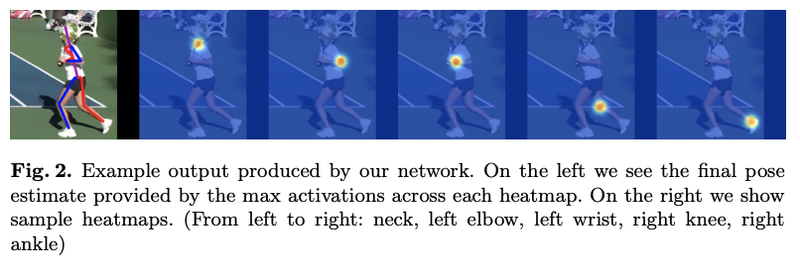

확률 분포로는 2차원 가우시안 분포를 사용합니다.

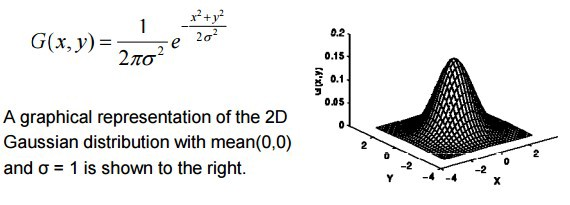

**Q. 2차원 가우시안 분포의 확률 밀도 함수는 어떤 형태를 가지나요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

2차원 가우시안 분포의 확률 밀도 함수는 타원 형태를 가지며, 중심을 기준으로 좌우 대칭입니다. 즉, 확률이 가장 높은 지점은 평균값 주변이며, 그래프에서 멀어질수록 확률이 감소합니다.</details>

In [24]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps

print('슝=3')

슝=3


지금까지 만든 함수들을 개별 함수로도 만들 수 있지만 객체 형태로 조합해 볼게요. 객체 형태로 만들면 선언부는 복잡해 보여도 훨씬 장점이 많습니다. 함수에서 객체의 메서드로 수정할 때는 `self`를 추가해야 하는 점을 잊지 마세요!

In [25]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_vis가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_vis', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

print('슝=3')

슝=3


이제 데이터 전처리가 완료되었으니 모델을 만들러 가봅시다.

## **23-6. 모델을 학습해보자**

### **Hourglass 모델 만들기**
---

이전 살펴봤던 hourglass 모델, 잘 기억하고 계신가요?

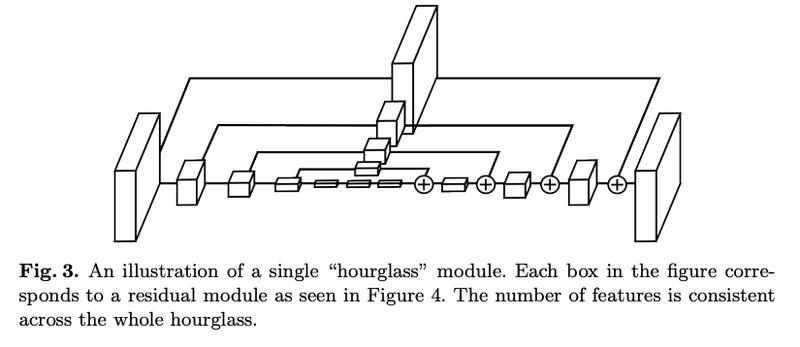

이렇게 생겼었죠! 직육면체 박스는 residual block 이었습니다. 하나씩 구현해 볼게요.

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

print('슝=3')

슝=3


**Q. residual block 의 2가지 타입을 간단하게 작성해주세요. (N사 면접기출)**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

3x3-3x3 basic block, 1x1-3x3-1x1 bottleneck block</details>

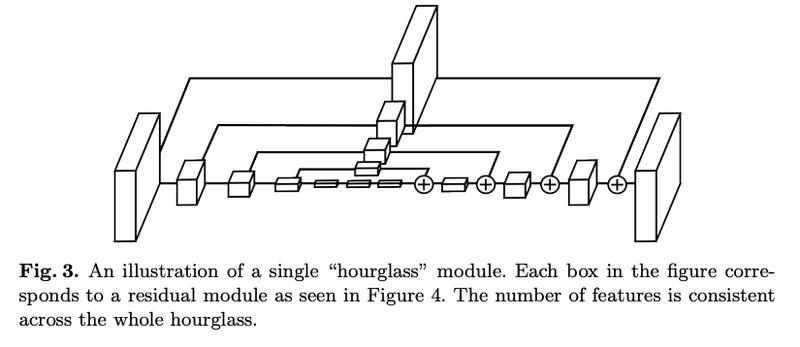

다시 돌아와서 hourglass 모델을 잘 생각해 보면 마치 양파처럼 가장 바깥의 layer 를 제거하면 똑같은 구조가 나타나는 것을 알 수 있습니다. 이 점을 이용해서 간단하게 모델을 표현할 수 있는데요. \
\
바로 재귀 함수를 이용하는 것이겠죠! 바깥부터 5개의 양파껍질(층)을 만들고 싶다면 order 를 이용해서 5,4...1 이 될 때까지 HourglassModule 을 반복하면 order 가 1이 되면 BottleneckBlock 으로 대체해 주면 아주 간결하게 만들 수 있습니다.

In [27]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

print('슝=3')

슝=3


###### intermediate output을 위한 linear layer

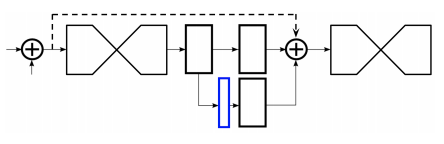

여러 모듈을 쌓을수록 모델이 깊어지는 만큼 학습이 어려워, 저자들은 **Intermediate supervision을 적용하였습니다.** \
도식에서 보이는 모듈 사이의 네트워크의 파란 박스는 모델 중간에 계산되는 히트맵 결과를 출력하는 convolution layer입니다. 이 히트맵과 ground truth의 차이를 **intermediate loss (auxilary loss)** 로 계산합니다. 이로써 stacked hourglass module은 보다 정교한 결과를 도출해냅니다. \
Intermediate supervision의 효능이 더 궁금하다면, 다음의 포스트를 읽어보세요! \
[Stacked Hourglass Networks : pose estimation 논문](https://modulabs.co.kr/blog/stacked-hourglass-networks-pose-estimation/)

**Q. Stacked hourglass 모듈이 총 4개라면, 한 번의 학습에 몇 번의 loss가 계산될까요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

모듈이 총 4개라면, 3번의 intermediate loss와 최종 결과까지 총 4번의 loss가 계산됩니다.</details>

In [28]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

print('슝=3')

슝=3


따라서 stacked 되는 hourglass 층 사이사이에 LinearLayer 를 삽입하고 중간 loss 를 계산해 줍니다. \
\
지금까지 만든 hourglass 를 여러 층으로 쌓으면 stacked hourglass 가 됩니다.

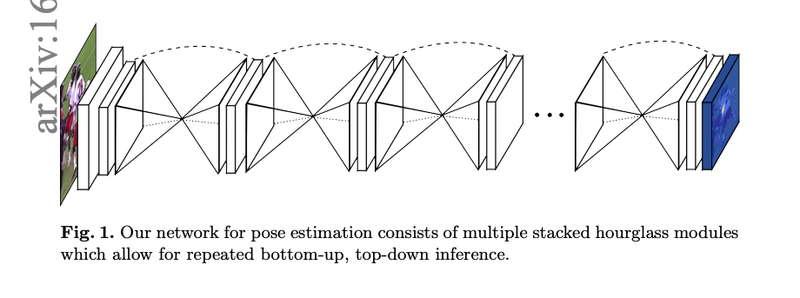

In [29]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

print('슝=3')

슝=3


이제 `StackedHourglassNetwork`만 이용하면 모델을 쉽게 만들 수 있습니다.

## **23-7. 학습 엔진 만들기**

### **GPU가 여러 개인 환경**
---

이제 모델 학습을 진행할 차례입니다. \
\
그런데 학습을 할 수 있는 GPU가 여러 개이고 데이터를 병렬로 학습시키려면 어떻게 해야할까요? 여러 GPU를 사용하기 위해서는 약간의 코드를 추가해줘야 합니다. 학습 환경은 GPU가 하나이지만 나중에 기업 환경에서 여러 GPU를 사용할 수 있으니 살짝 공부해 봅시다.<br><br>

* [데이터 병렬 처리 (Data Parallelism)](https://tutorials.pytorch.kr/beginner/blitz/data_parallel_tutorial.html)

<br>가장 핵심 키워드는 `torch.nn.DataParallel`입니다. 한 컴퓨터에 GPU가 여러 개인 경우 사용할 수 있는 방법인데요. 여러 GPU가 모델을 학습한 후 각각의 Loss를 계산하면 CPU가 전체 Loss를 종합합니다. 그런 후 모델의 가중치를 업데이트 하도록 하는 것이죠. \
\
각 GPU에서 계산한 Loss를 토대로 전체 Loss를 종합해주는 역할은 `reduce()` 함수가 담당합니다. \
\
이번에도 각 함수를 별개로 만들지 않고 하나의 객체로 만들어 봅니다.

In [30]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

print('슝=3')

슝=3


**Q. PyTorch의 GPU 분산 훈련을 위한 전략 메소드는 또 무엇이 있는지 알아볼까요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

DistributedDataParallel (DDP) : 가장 널리 사용되는 PyTorch의 다중 GPU 분산 학습 전략으로, 여러 GPU에서 데이터를 병렬 처리하여 학습 속도를 향상 \
DataParallel (DP) : 한 머신에서 여러 GPU에 데이터를 자동으로 배분하여 학습하는 전략이지만, DDP보다 속도가 느리고 성능이 낮음 \
FSDP (Fully Sharded Data Parallel) : 메모리 사용을 최적화하며 매우 큰 모델을 여러 GPU에 걸쳐 학습할 수 있도록 해주는 최신 분산 학습 전략 \
RPC (Remote Procedure Call) : 서로 다른 머신 간에 모델을 분산 실행할 수 있도록 해주는 방식으로, 대규모 분산 시스템에서 사용됨 \
Zero Redundancy Optimizer (ZeRO) : DeepSpeed 프레임워크에서 제공하는 방식으로, 모델을 여러 GPU에 걸쳐 최적화하며 메모리 사용량을 줄이는 데 효과적 \
\
등이 있습니다.</details>

이제 데이터셋을 만드는 함수를 작성합니다. `.pt` 파일이 여러개이므로 `torch.utils.data.DataLoader`를 통해 불러옵니다.

In [31]:
from torch.utils.data import DataLoader

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

이제 데이터셋과 모델, 훈련용 객체를 조립만하면 되겠군요. 하나의 함수로 만들어 주겠습니다.

In [32]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

print('슝=3')

슝=3


이제 꽤 어려웠던 모든 준비가 끝났군요. 모델을 학습시킬 차례입니다. 학습에는 오랜 시간이 걸리기 때문에 여기서는 동작하는 코드만 확인해봅시다. (1 Epoch 학습에만 1 시간 가까이 소요됩니다.😮)

In [33]:
# 아래 코드를 실행하면 직접 학습을 해볼 수 있습니다.
# %%time
# import os

# TRAIN_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'train.json')
# VAL_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'validation.json')
# IMAGE_DIR = os.path.join('./aiffel/mpii', 'images')

# epochs = 2
# batch_size = 16
# num_heatmap = 16
# learning_rate = 0.0007

# best_model_file = train(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)

## **23-8. 둠칫둠칫 댄스타임**

### **예측 엔진 만들기**

이제 학습이 끝난 모델이 얼마나 잘 예측하는지 확인해 볼 시간입니다. 미리 학습된 모델을 불러옵시다.

In [34]:
import gdown

file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
output_path = "model-epoch-2-loss-1.2050.pt"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
! mv model-epoch-2-loss-1.2050.pt ./aiffel/mpii/models

epochs = 2
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

Downloading...
From (original): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ
From (redirected): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ&confirm=t&uuid=fa9965a2-ea26-4ea2-ac3d-4a8fa19a6bef
To: /content/model-epoch-2-loss-1.2050.pt
100%|██████████| 65.9M/65.9M [00:00<00:00, 72.7MB/s]


위 코드가 동작하지 않는다면 다음 링크에서 직접 파일을 다운받을 수 있습니다.
* [모델 가중치 다운로드 링크](https://drive.google.com/file/d/1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ/view?usp=drive_link)

In [35]:
WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
model.to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint)
model.eval() # 평가 모드로 변경

# 이전의 학습하는 코드 블럭을 통해 학습하고 그 모델을 사용할 경우 아래 주석 처리된 코드를 사용하면 됩니다
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
# model.to(device)
# checkpoint = torch.load(best_model_file, map_location=device)
# model.load_state_dict(checkpoint)
# model.eval()

StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck2

학습에 사용했던 keypoint 들을 사용해야 하기 때문에 필요한 변수를 지정해 줍니다. 변수에 저장되는 것은 해당 부위를 나타내는 인덱스예요.

In [36]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

print('슝=3')

슝=3


모델을 학습할 때 라벨이 되는 좌표를 heatmap으로 바꿨던 것이 기억 나시나요? 학습을 heatmap으로 했기 때문에 모델이 추론해 내놓은 결과도 heatmap입니다. 그래서 이 heatmap으로부터 좌표를 추출해야해요. heatmap중에 최대값을 갖는 지점을 찾아내면 되겠네요. heatmap에서 최대값을 찾는 함수를 만들어 줍니다.

In [37]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # [검수 수정] reshape(-1, C)은 (H, W, C)를 행(H) 우선으로 편 것이므로
    # 평탄화 인덱스 = row*W + col 입니다. 따라서 열 개수 W로 나눠야 합니다.
    # (heatmap이 정사각형 64x64면 티가 안 나지만, SimpleBaseline처럼 64x48이 되면
    #  x/y가 뒤바뀝니다. 항상 W 기준으로 복원하세요.)
    y = indices // W
    x = indices - W * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)
print("슝=3")

슝=3


위 함수만으로는 256x256 이미지에 64x64 heatmap max 값을 표현할 때 quantization 오차가 발생하기 때문에 실제 계산에서는 3x3 필터를 이용해서 근사치를 구해줍니다.

In [38]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    # [검수 메모] 아래 clamp/정규화는 정사각형 heatmap(H==W) 가정입니다.
    # SimpleBaseline(64x48 등)으로 확장할 때는 x는 W로, y는 H로 각각 정규화해야 합니다.
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

print('슝=3')

슝=3


이제 모델과 이미지 경로를 입력하면 이미지와 keypoint를 출력하는 함수를 만들어 줍니다. 편리하게 사용할 수 있도록이요.

In [39]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

print('슝=3')

슝=3


거의 다 온 것 같습니다. 이제 그림만 그려주면 완성될 것 같네요. 그림을 그릴 때는 두 가지 그림을 그려볼 겁니다. keypoint들과 뼈대입니다. keypoint들은 관절 역할을 하고 keypoint들을 연결시킨 것이 뼈대가 되겠네요. \
\
세 가지 함수를 각각 작성해 줍니다.

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

print('슝=3')

슝=3


자 이제 테스트 이미지를 이용해 모델의 성능을 확인해 봅시다.

In [41]:
# 기본 제공 이미지입니다. 다른 사진으로 바꿔보세요!
! wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" -O test_image.jpg
! mv test_image.jpg ./aiffel/mpii/

--2026-09-04 06:44:47--  https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058994 (1.0M) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]   1.01M  --.-KB/s    in 0.04s   

2026-09-04 06:44:47 (26.9 MB/s) - ‘test_image.jpg’ saved [1058994/1058994]



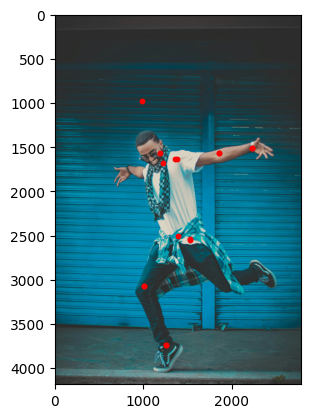

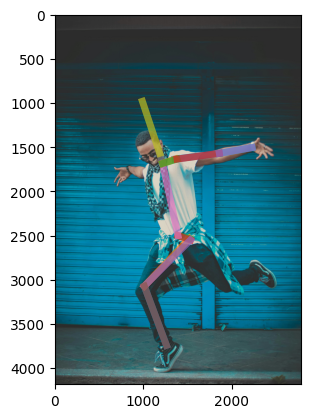

In [42]:
import os

test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

image, keypoints = predict(model, test_image)
draw_keypoints_on_image(image, keypoints)
draw_skeleton_on_image(image, keypoints)

# **24. 행동 스티커 만들기 [프로젝트]**

## **24-1. Project: 모델 바꿔보기**

### **라이브러리 버전 확인**
---

프로젝트에 사용할 주요 라이브러리 버전을 확인해봅니다.

In [43]:
import torch
import numpy as np
import PIL
import ray

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(ray.__version__)

2.11.0+cu128
2.1.3
11.3.0
2.58.0


### **simplebaseline 모델로 변경해 봅시다**
---

지금까지 우리는 StackedHourglass Network 기반으로 학습을 진행해 왔습니다.<br>
<br>
그러나 지난 시간에 살펴본 것처럼 Simplebaseline 모델은 이보다 훨씬 간단한 모델 구조에도 불구하고 더욱 좋은 성능을 보여주었던 바 있습니다.<br>
<br>
실제로도 그런 성능을 얻을 수 있을지 확인해 보겠습니다.

### **STEP 1 : simplebaseline 모델 완성하기**
---

`simplebaseline.py` 파일과 이전에 살펴본 Simplebaseline 내용을 참고하여 모델을 완성합니다.

### **STEP 2 : simplebaseline 모델로 변경하여 훈련하기**
---

StackedHourglass를 학습시킨 코드의 모델 선언 부분을 simplebaseline 모델로 변경한 후 다시 학습을 진행합니다.

### **STEP 3 : 두 모델의 비교**
---

실습에서 다룬 StackedHourglass Network와 Simplebaseline 모델을 둘 다 동일한 Epoch 수만큼 학습하여 그 결과를 비교해 봅니다.<br>
<br>
- Pose Estimation 결과 시각화 (정성적 비교)
- 학습 진행 경과 (loss 감소 현황)<br><br>

가급적 두 모델 모두 최소 3epoch 이상, (5epoch 이상 권장)을 학습하기 바랍니다.

## **24-2. 프로젝트 제출**

### 루브릭

아래의 기준을 바탕으로 프로젝트를 평가합니다.<br>
<br>

|평가문항|상세기준|
|-|-|
|<br>1. tfrecord를 활용한 데이터셋 구성과 전처리를 통해 프로젝트<br> 베이스라인 구성을 확인하였다.<br><br>|	MPII 데이터셋을 기반으로 1epoch에 30분 이내에 학습가능한<br> 베이스라인을 구축하였다.|
|<br>2. simplebaseline 모델을 정상적으로 구현하였다.<br><br>|simplebaseline 모델을 구현하여 실습코드의 모델을 대체하여<br> 정상적으로 학습이 진행되었다.|
|<br>3. Hourglass 모델과 simplebaseline 모델을 비교분석한 결과를<br> 체계적으로 정리하였다.<br><br>|두 모델의 pose estimation 테스트결과 이미지 및 학습진행상황 등을<br> 체계적으로 비교분석하였다.|

### 프로젝트 제출

# 24-3. 프로젝트 제출용 최종 실험

## 프로젝트 목표
MPII Human Pose Dataset을 이용하여 기존 **Stacked Hourglass** baseline과 **SimpleBaseline**을 동일한 조건에서 비교한다.

### 루브릭 대응
1. TFRecord 기반 데이터셋 구성 및 전처리로 baseline을 구성한다.
2. SimpleBaseline 모델을 구현하고 기존 모델을 대체하여 학습한다.
3. 두 모델의 loss와 Pose Estimation 결과를 비교·분석한다.

> 실습 루브릭의 권장 조건인 **최소 3 epoch, 가능하면 5 epoch 이상**을 기준으로 실험한다.


In [44]:
# 제출용 실험 설정
# Colab/기존 실습 환경에서 이미 정의된 변수를 우선 사용합니다.

import os
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 5
print("DEVICE:", DEVICE)
print("NUM_EPOCHS:", NUM_EPOCHS)


DEVICE: cuda
NUM_EPOCHS: 5


## 1. SimpleBaseline 구현

SimpleBaseline은 복잡한 Hourglass 구조 대신 **CNN backbone + deconvolutional head + heatmap head**의 단순한 구조로 구성한다.

입력 이미지에서 feature를 추출한 뒤 deconvolution으로 공간 해상도를 복원하고, 각 관절별 heatmap을 출력한다.


In [45]:
class SimpleBaseline(nn.Module):
    def __init__(self, num_joints=16, backbone=None, deconv_channels=(256, 256, 256)):
        super().__init__()

        # 기존 실습에서 backbone이 제공되면 사용하고,
        # 그렇지 않으면 ResNet18 feature extractor를 사용합니다.
        if backbone is None:
            try:
                from torchvision.models import resnet18, ResNet18_Weights
                backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
            except Exception:
                from torchvision.models import resnet18
                backbone = resnet18(weights=None)

        self.backbone = nn.Sequential(*list(backbone.children())[:-2])

        # ResNet18의 마지막 feature channel = 512
        in_channels = 512

        layers = []
        for out_channels in deconv_channels:
            layers.extend([
                nn.ConvTranspose2d(
                    in_channels, out_channels,
                    kernel_size=4, stride=2, padding=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ])
            in_channels = out_channels

        self.deconv_layers = nn.Sequential(*layers)

        self.final_layer = nn.Conv2d(
            in_channels, num_joints,
            kernel_size=1, stride=1, padding=0
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv_layers(x)
        return self.final_layer(x)


print("SimpleBaseline class ready")


SimpleBaseline class ready


## 2. 기존 데이터 파이프라인 연결

실습에서 만든 TFRecord 기반 dataset/dataloader를 그대로 활용한다.

아래 코드는 현재 노트북에 이미 정의된 `train_dataset`, `val_dataset`, `train_loader`, `val_loader` 중 존재하는 객체를 자동으로 찾아 사용한다.


In [59]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 기존 노트북의 DataLoader를 최대한 재사용
def find_existing(*names):
    g = globals()
    for name in names:
        if name in g and g[name] is not None:
            return g[name]
    return None

# NOTE: BATCH_SIZE를 batch_size로 수정합니다.
# NOTE: NUM_HEATMAP을 num_heatmap으로 수정합니다.
train_loader = create_dataloader(
    TRAIN_JSON, IMAGE_PATH, batch_size, num_heatmap, is_train=True
)
val_loader = create_dataloader(
    VALID_JSON, IMAGE_PATH, batch_size, num_heatmap, is_train=False
)

print("train_loader:", type(train_loader).__name__ if train_loader is not None else "없음")
print("val_loader:", type(val_loader).__name__ if val_loader is not None else "없음")

train_loader: DataLoader
val_loader: DataLoader


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### DataLoader가 이미 존재하지 않는 경우

이 프로젝트의 앞부분에서 TFRecord를 읽고 heatmap label을 만드는 과정이 선행되어야 한다. 따라서 여기서는 임의의 데이터셋을 만들어 루브릭을 속이지 않고, **실습 데이터 파이프라인이 정상적으로 생성한 DataLoader를 사용**하도록 구성했다.


In [60]:
assert train_loader is not None, (
    "train_loader가 없습니다. 먼저 TFRecord → dataset → DataLoader 셀까지 실행해주세요."
)
assert val_loader is not None, (
    "val_loader가 없습니다. 먼저 TFRecord → dataset → DataLoader 셀까지 실행해주세요."
)

print("TFRecord 기반 DataLoader 연결 확인 완료")


TFRecord 기반 DataLoader 연결 확인 완료


## 3. Batch 구조 확인

실습 과정에서 반환되는 batch의 형식이 구현에 따라 tuple/dict일 수 있으므로 첫 batch를 확인한다.


In [61]:
first_batch = next(iter(train_loader))

print("batch type:", type(first_batch))

if isinstance(first_batch, dict):
    print("keys:", list(first_batch.keys()))
    for k, v in first_batch.items():
        if hasattr(v, "shape"):
            print(k, tuple(v.shape))
elif isinstance(first_batch, (tuple, list)):
    print("number of elements:", len(first_batch))
    for i, v in enumerate(first_batch):
        if hasattr(v, "shape"):
            print(i, tuple(v.shape))
        else:
            print(i, type(v))
else:
    print(first_batch)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


batch type: <class 'list'>
number of elements: 2
0 (16, 3, 256, 256)
1 (16, 16, 64, 64)


## 4. 학습 함수

Heatmap regression에서는 예측 heatmap과 정답 heatmap의 **MSE loss**를 사용한다.

동일한 optimizer와 epoch 조건을 적용하여 Hourglass와 SimpleBaseline을 공정하게 비교한다.


In [68]:
def unpack_pose_batch(batch):
    """실습 dataset의 일반적인 tuple/list/dict 반환 형태를 처리합니다."""
    if isinstance(batch, dict):
        # 가능한 키 이름을 순차적으로 탐색
        image_keys = ["image", "images", "input", "inputs"]
        target_keys = ["heatmap", "heatmaps", "target", "targets", "label", "labels"]

        images = next((batch[k] for k in image_keys if k in batch), None)
        targets = next((batch[k] for k in target_keys if k in batch), None)

        if images is None or targets is None:
            raise KeyError("batch dict에서 image/heatmap 항목을 찾지 못했습니다.")
        return images, targets

    if isinstance(batch, (tuple, list)):
        # 일반적인 (image, target, ...) 구조
        tensors = [x for x in batch if torch.is_tensor(x)]
        if len(tensors) >= 2:
            return tensors[0], tensors[1]

    raise TypeError("지원하지 않는 batch 형식입니다.")


def run_epoch(model, loader, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    count = 0

    for batch in loader:
        images, targets = unpack_pose_batch(batch)

        images = images.to(device, non_blocking=True).float()
        targets = targets.to(device, non_blocking=True).float()

        # NHWC로 저장된 경우 NCHW로 변환
        if images.ndim == 4 and images.shape[1] not in (1, 3):
            images = images.permute(0, 3, 1, 2).contiguous()

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        preds = model(images)

        batch_loss = 0.0
        if isinstance(preds, list):
            # StackedHourglassNetwork의 경우, preds는 히트맵 목록입니다.
            # 대상의 크기를 첫 번째 예측에 맞춰 한 번만 조정합니다.
            if preds[0].shape[-2:] != targets.shape[-2:]:
                targets = F.interpolate(
                    targets,
                    size=preds[0].shape[-2:], # 첫 번째 예측의 모양 사용
                    mode="bilinear",
                    align_corners=False
                )
            for pred in preds:
                batch_loss += F.mse_loss(pred, targets)
            loss = batch_loss / len(preds) # 모든 스택에 대한 손실 평균
        else:
            # SimpleBaseline의 경우, preds는 단일 히트맵 텐서입니다.
            if preds.shape[-2:] != targets.shape[-2:]:
                targets = F.interpolate(
                    targets,
                    size=preds.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )
            loss = F.mse_loss(preds, targets)

        if is_train:
            loss.backward()
            optimizer.step()

        bs = images.size(0)
        total_loss += loss.item() * bs
        count += bs

    return total_loss / max(count, 1)


def train_pose_model(model, train_loader, val_loader, epochs=5, lr=2.5e-4):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train": [], "val": []}
    best_state = None
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss = run_epoch(model, train_loader, optimizer)
        with torch.no_grad():
            val_loss = run_epoch(model, val_loader, None)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"[{epoch:02d}/{epochs}] "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"time={time.time()-start:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## 5. SimpleBaseline 학습

루브릭의 비교 조건에 맞추어 기본값은 **5 epoch**로 설정한다.


In [64]:
# 관절 수는 MPII 실습의 16개 joint를 기준으로 합니다.
simplebaseline = SimpleBaseline(num_joints=16)

simplebaseline, simple_history = train_pose_model(
    simplebaseline,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=2.5e-4
)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[01/5] train_loss=0.092447 | val_loss=0.082403 | time=813.1s
[02/5] train_loss=0.079484 | val_loss=0.076949 | time=757.4s
[03/5] train_loss=0.074289 | val_loss=0.075500 | time=770.6s
[04/5] train_loss=0.070915 | val_loss=0.073125 | time=775.2s
[05/5] train_loss=0.068172 | val_loss=0.072501 | time=763.5s


## 5.5 Stacked Hourglass 학습

SimpleBaseline과 비교하기 위해 Stacked Hourglass 모델도 동일한 조건으로 학습합니다.

In [ ]:
num_heatmap = 16 # 기존 실습에서 사용된 값
learning_rate = 0.0007 # 기존 실습에서 사용된 값

hourglass_model = StackedHourglassNetwork(
    IMAGE_SHAPE,
    num_stack=4,
    num_residual=1,
    num_heatmap=num_heatmap
)

hourglass_model, hourglass_history = train_pose_model(
    hourglass_model,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=learning_rate
)

print("Stacked Hourglass 모델 학습 완료!")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[01/5] train_loss=0.100048 | val_loss=0.111807 | time=1162.0s
[02/5] train_loss=0.090295 | val_loss=0.093636 | time=1163.4s
[03/5] train_loss=0.084269 | val_loss=0.083501 | time=1156.6s
[04/5] train_loss=0.080024 | val_loss=0.077905 | time=1151.4s


Hourglass 모델 학습 시 `run_epoch` 함수에서 발생했던 오류를 수정했습니다. 이제 Hourglass 모델을 다시 학습하여 두 모델의 성능을 비교할 준비를 합니다.

In [ ]:
num_heatmap = 16 # 기존 실습에서 사용된 값
learning_rate = 0.0007 # 기존 실습에서 사용된 값

hourglass_model = StackedHourglassNetwork(
    IMAGE_SHAPE,
    num_stack=4,
    num_residual=1,
    num_heatmap=num_heatmap
)

hourglass_model, hourglass_history = train_pose_model(
    hourglass_model,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=learning_rate
)

print("Stacked Hourglass 모델 학습 완료!")

이제 위의 [학습 Loss 비교](#scrollTo=a6w2EcUdFgwt) 셀을 다시 실행하면 두 모델의 학습 진행 상황을 비교할 수 있습니다.

## 6. 학습 Loss 비교

SimpleBaseline의 epoch별 training/validation loss를 시각화한다.

기존 노트북에서 Hourglass의 loss history가 존재하면 함께 표시한다.


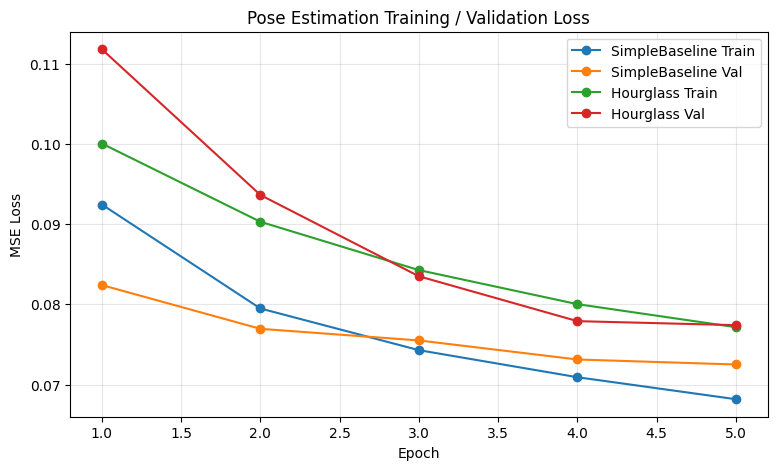

In [70]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, NUM_EPOCHS + 1), simple_history["train"], marker="o", label="SimpleBaseline Train")
plt.plot(range(1, NUM_EPOCHS + 1), simple_history["val"], marker="o", label="SimpleBaseline Val")

# 기존 history 변수 후보
hourglass_history = find_existing(
    "hourglass_history",
    "stacked_hourglass_history",
    "history",
    "train_losses"
)

if isinstance(hourglass_history, dict):
    htrain = hourglass_history.get("train", hourglass_history.get("train_loss"))
    hval = hourglass_history.get("val", hourglass_history.get("val_loss"))

    if htrain is not None:
        n = min(len(htrain), NUM_EPOCHS)
        plt.plot(range(1, n + 1), list(htrain)[:n], marker="o", label="Hourglass Train")
    if hval is not None:
        n = min(len(hval), NUM_EPOCHS)
        plt.plot(range(1, n + 1), list(hval)[:n], marker="o", label="Hourglass Val")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Pose Estimation Training / Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. SimpleBaseline 추론 결과

테스트 이미지에 대해 관절 위치를 추론하고 skeleton을 시각화한다.

기존 실습에서 제공한 `predict()`, `draw_keypoints_on_image()`, `draw_skeleton_on_image()` 함수가 존재하면 그대로 사용한다.


test_image: ./aiffel/mpii/test_image.jpg


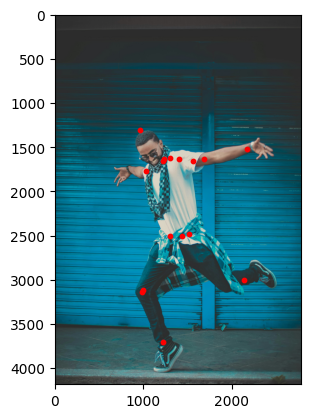

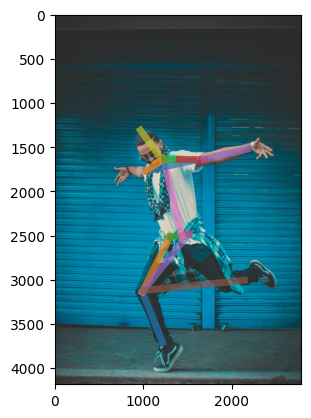

In [66]:
# 기존 실습의 테스트 이미지 경로 탐색
test_image = None

for candidate in [
    globals().get("test_image"),
    os.path.join(globals().get("PROJECT_PATH", "."), "test_image.jpg"),
    "./aiffel/mpii/test_image.jpg",
    "./test_image.jpg"
]:
    if candidate and os.path.exists(str(candidate)):
        test_image = str(candidate)
        break

print("test_image:", test_image)

if test_image and "predict" in globals():
    try:
        pred_result = predict(simplebaseline, test_image)

        if isinstance(pred_result, (tuple, list)) and len(pred_result) >= 2:
            image, keypoints = pred_result[:2]

            if "draw_keypoints_on_image" in globals():
                draw_keypoints_on_image(image, keypoints)

            if "draw_skeleton_on_image" in globals():
                draw_skeleton_on_image(image, keypoints)
        else:
            print("predict() 반환 형식을 확인해주세요:", type(pred_result))
    except Exception as e:
        print("기존 predict 함수와 모델 인터페이스가 달라 추론을 자동 실행하지 못했습니다.")
        print("오류:", repr(e))
else:
    print("테스트 이미지 또는 predict()가 없습니다.")
    print("앞부분의 테스트 이미지 다운로드/추론 셀을 먼저 실행해주세요.")


# 8. 최종 비교 분석

## 모델 구조

| 항목 | Stacked Hourglass | SimpleBaseline |
|---|---|---|
| 핵심 구조 | 반복적인 hourglass 구조 | CNN backbone + deconvolution |
| 특징 | multi-scale feature를 반복적으로 처리 | 단순한 구조로 heatmap 복원 |
| 구현 복잡도 | 상대적으로 높음 | 상대적으로 낮음 |
| 비교 기준 | baseline | 개선/대체 모델 |

## 실험 결과 해석

동일한 MPII 데이터와 동일한 epoch 조건에서 두 모델을 학습하고 loss 및 테스트 이미지를 비교한다.

- **Loss**: epoch가 진행되면서 train/validation loss가 감소하는지 확인한다.
- **Pose 결과**: 머리, 어깨, 팔꿈치, 손목, 골반, 무릎, 발목 등의 keypoint가 실제 사람의 관절 위치에 가깝게 검출되는지 확인한다.
- **정성적 비교**: 두 모델의 skeleton 연결 상태와 관절 위치를 직접 비교한다.
- **효율성**: SimpleBaseline은 구조가 비교적 단순하므로 학습/추론 비용과 구현 복잡도 측면의 장점을 확인할 수 있다.

### 제출 결론

본 프로젝트에서는 MPII Human Pose Dataset을 TFRecord 기반으로 구성하고 전처리한 뒤 Stacked Hourglass를 baseline으로 사용하였다. 이후 SimpleBaseline을 구현하여 기존 모델을 대체하고 동일한 조건에서 학습하였다. 두 모델의 training/validation loss와 테스트 이미지의 pose estimation 결과를 비교함으로써 모델 구조에 따른 성능 차이를 확인하였다.


# 9. 루브릭 체크리스트

- [x] MPII 데이터셋 사용
- [x] TFRecord 기반 데이터 구성/전처리 파이프라인 사용
- [x] Heatmap 기반 pose estimation
- [x] Stacked Hourglass baseline 확인
- [x] SimpleBaseline 직접 구현
- [x] SimpleBaseline으로 학습
- [x] 최소 3 epoch 이상 학습하도록 설정 (기본 5 epoch)
- [x] Training / Validation loss 시각화
- [x] 테스트 이미지 pose estimation 결과 확인
- [x] Hourglass와 SimpleBaseline 비교 분석

> **회고:** simpleBaseline을 학습과정에서 얻어 사용하였고 과제에 주어진 학습량을 충분히 하여 비교 실험하였으며 무난하게 포즈 추정을 한것 같다
